### EDA for our data to check for any pre-processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/census.csv")
df.head()

,age,workclass,fnlgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlgt           32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  salary          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.isna().sum()

age               0
workclass         0
fnlgt             0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64

In [5]:
df['salary'].value_counts()

salary
<=50K    24720
>50K      7841
Name: count, dtype: int64

### Understanding correlations

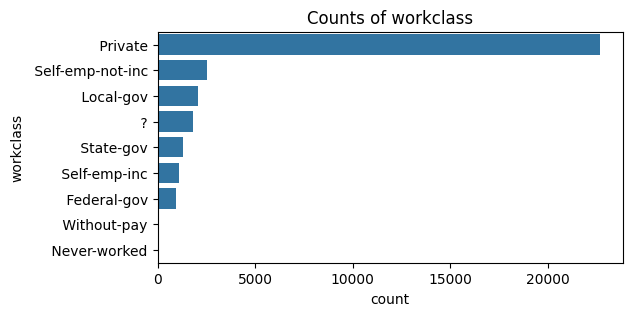

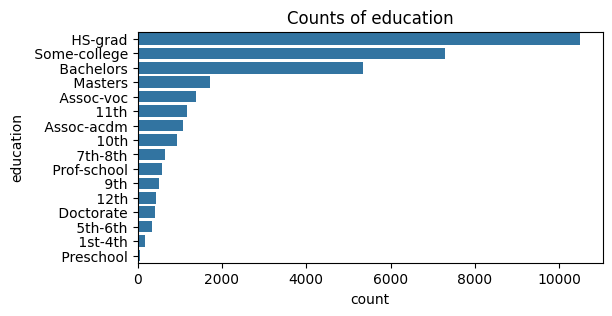

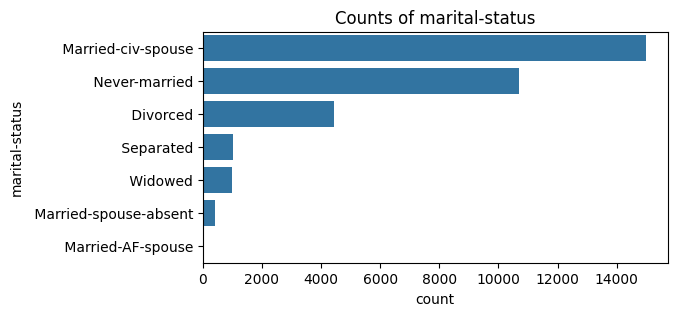

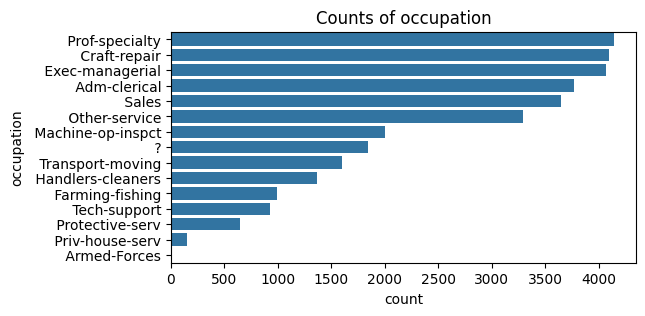

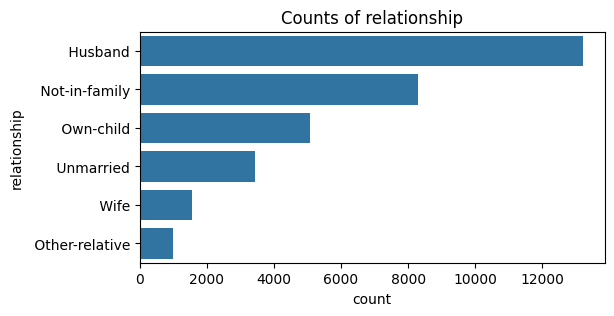

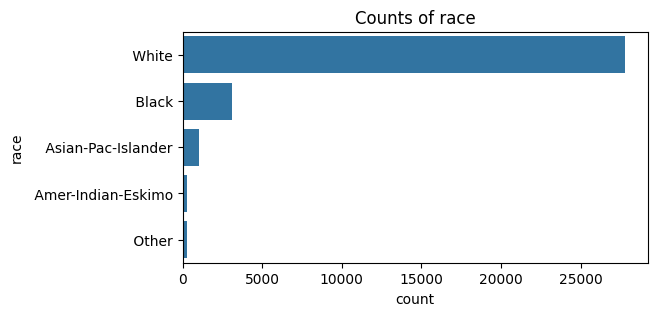

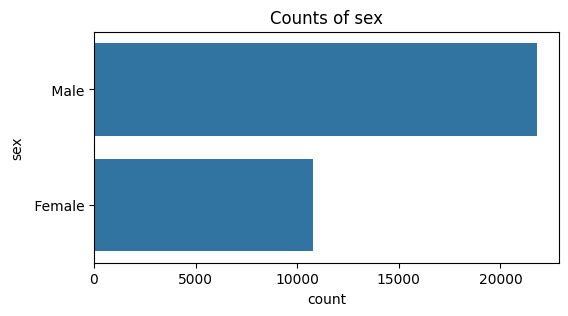

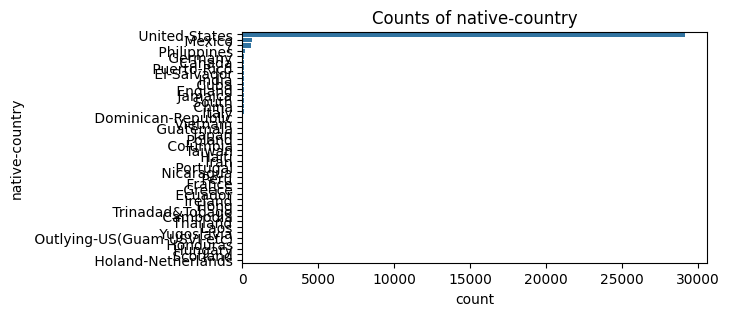

In [6]:
categorical_cols = [
    "workclass", "education", "marital-status",
    "occupation", "relationship", "race", "sex", "native-country"
]

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Counts of {col}")
    plt.show()

In [8]:
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['salary'], normalize='index')
    print(f"\n{col} vs salary:")
    print(ct)


workclass vs salary:
salary               <=50K      >50K
workclass                           
?                 0.895969  0.104031
Federal-gov       0.613542  0.386458
Local-gov         0.705208  0.294792
Never-worked      1.000000  0.000000
Private           0.781327  0.218673
Self-emp-inc      0.442652  0.557348
Self-emp-not-inc  0.715073  0.284927
State-gov         0.728043  0.271957
Without-pay       1.000000  0.000000

education vs salary:
salary           <=50K      >50K
education                       
10th          0.933548  0.066452
11th          0.948936  0.051064
12th          0.923788  0.076212
1st-4th       0.964286  0.035714
5th-6th       0.951952  0.048048
7th-8th       0.938080  0.061920
9th           0.947471  0.052529
Assoc-acdm    0.751640  0.248360
Assoc-voc     0.738784  0.261216
Bachelors     0.585247  0.414753
Doctorate     0.259080  0.740920
HS-grad       0.840491  0.159509
Masters       0.443413  0.556587
Preschool     1.000000  0.000000
Prof-school   0.26562

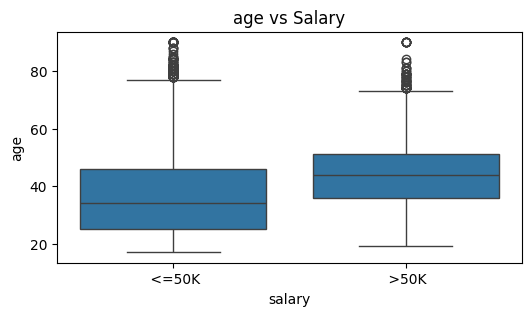

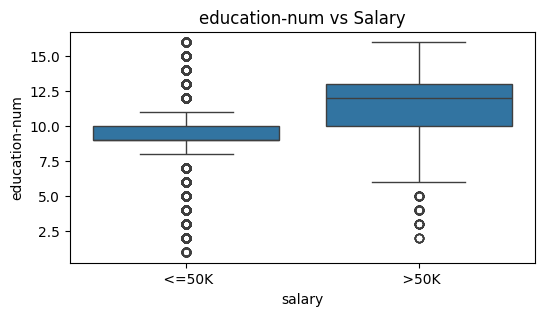

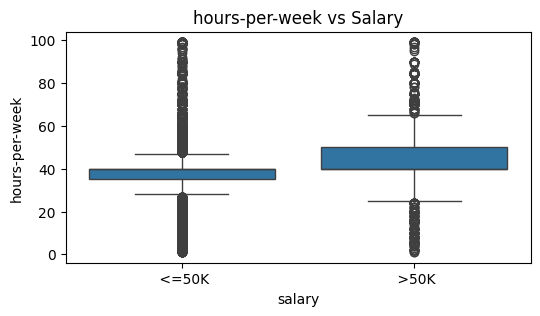

In [9]:
numeric_cols = ['age', 'education-num', 'hours-per-week']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='salary', y=col, data=df)
    plt.title(f"{col} vs Salary")
    plt.show()

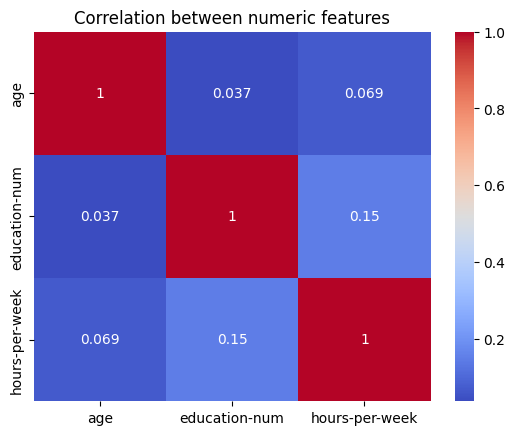

In [11]:
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.show()